# 02 — Univariate Factor Screen

For every (portfolio, factor) pair, run an OLS regression of the form

$$r^{excess}_{i,t} = \alpha_i + \beta_{i,f}\,r^{excess}_{f,t} + \varepsilon_{i,t}$$

and record β, t-stat, p-value, R². Then score each factor across the 6 portfolios (5 assets + EWP) so we can see which factors are **stable across portfolios**.

Reference: Class 4 slides — start with a wide net, score by significance.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

DATA = Path('..').resolve() / 'data'
assets   = pd.read_csv(DATA / 'assets_excess.csv',  index_col=0, parse_dates=True)
factors  = pd.read_csv(DATA / 'factors_excess.csv', index_col=0, parse_dates=True)
print('assets  :', assets.shape, '| cols:', list(assets.columns))
print('factors :', factors.shape)

assets  : (120, 6) | cols: ['Asset 1', 'Asset 2', 'Asset 3', 'Asset 4', 'Asset 5', 'EWP']
factors : (120, 26)


## 2.1 — Run the full univariate grid

In [2]:
def univariate_ols(y, x):
    X = sm.add_constant(x)
    m = sm.OLS(y, X, missing='drop').fit()
    return {
        'alpha'   : m.params['const'],
        'beta'    : m.params[x.name],
        't_alpha' : m.tvalues['const'],
        't_beta'  : m.tvalues[x.name],
        'p_beta'  : m.pvalues[x.name],
        'rsq'     : m.rsquared,
        'adj_rsq' : m.rsquared_adj,
        'n'       : int(m.nobs),
    }

rows = []
for a in assets.columns:
    for f in factors.columns:
        r = univariate_ols(assets[a], factors[f])
        r.update(portfolio=a, factor=f)
        rows.append(r)

uni = pd.DataFrame(rows)
uni.head()

,alpha,beta,t_alpha,t_beta,p_beta,rsq,adj_rsq,n,portfolio,factor
0,0.001619,0.414434,2.717600,7.300412,3.638119e-11,0.311134,0.305296,120,Asset 1,US Muni
1,0.001344,1.397826,2.596682,10.498855,1.308659e-18,0.482969,0.478587,120,Asset 1,US Tbill 1-3yr
2,0.000768,0.699306,2.386877,21.940125,1.857273e-43,0.803126,0.801458,120,Asset 1,US AGG
3,0.001805,0.272038,3.166518,8.106690,5.470985e-13,0.357713,0.352270,120,Asset 1,Global AGG
4,0.002397,-0.035793,3.390625,-0.898776,3.706022e-01,0.006799,-0.001618,120,Asset 1,US Dollar


## 2.2 — R² heatmap (factor vs portfolio)

A visual first pass: factors that light up bright across **every** row are candidates for the stable set.

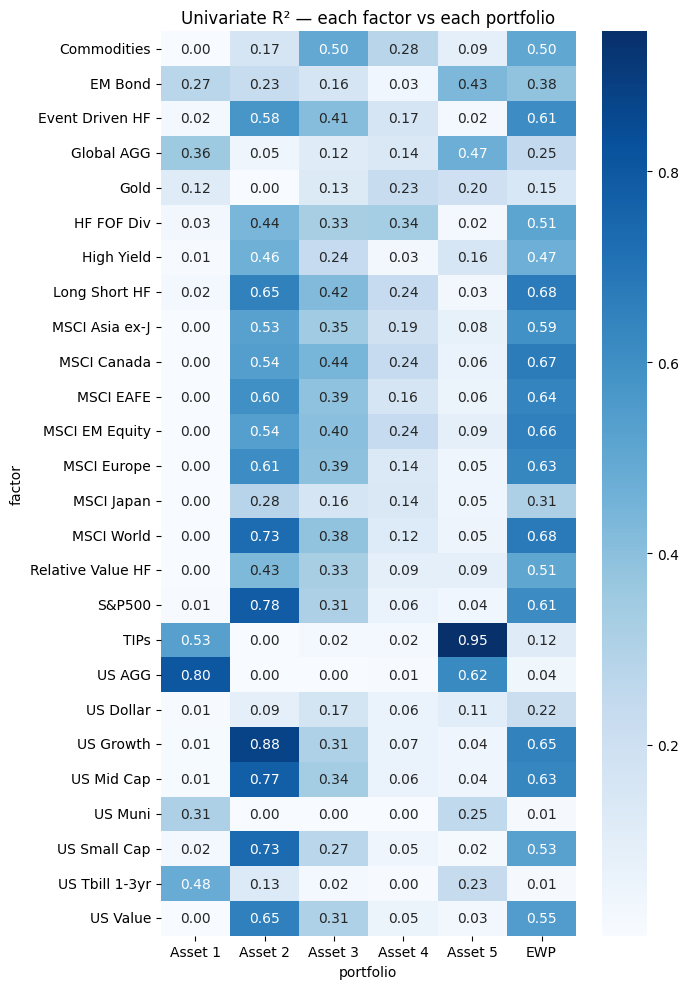

In [3]:
rsq_mat = uni.pivot(index='factor', columns='portfolio', values='rsq')
fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(rsq_mat, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=ax)
ax.set_title('Univariate R² — each factor vs each portfolio')
plt.tight_layout()
plt.show()

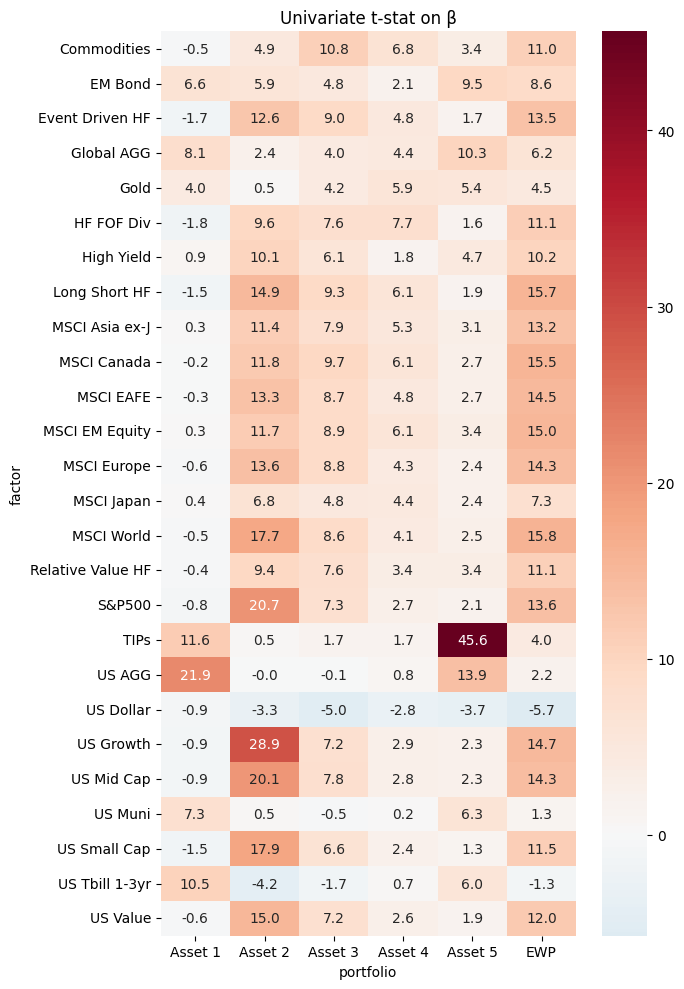

In [4]:
tstat_mat = uni.pivot(index='factor', columns='portfolio', values='t_beta')
fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(tstat_mat, annot=True, fmt='.1f', center=0, cmap='RdBu_r', ax=ax)
ax.set_title('Univariate t-stat on β')
plt.tight_layout()
plt.show()

## 2.3 — Score factors by *cross-portfolio* stability

For each factor:
- `hits_95` = # of the 6 portfolios where |t|>1.96 (~95% significance)
- `hits_90` = # where |t|>1.65 (~90%)
- `median_rsq` = median R² across portfolios
- `sign_consistency` = |mean(sign(β))| — 1.0 if the factor has the same sign on every portfolio, 0 if evenly split
- `beta_cv` = std(β) / |mean(β)| — dispersion of β across portfolios

A factor that is *stable across portfolios* should score high on `hits`, high on `sign_consistency`, and have a reasonable `median_rsq`.

In [5]:
def score_factor(group):
    t = group['t_beta'].values
    b = group['beta'].values
    return pd.Series({
        'hits_95'         : int((np.abs(t) > 1.96).sum()),
        'hits_90'         : int((np.abs(t) > 1.65).sum()),
        'median_rsq'      : np.median(group['rsq']),
        'mean_rsq'        : np.mean(group['rsq']),
        'sign_consistency': np.abs(np.sign(b).mean()),
        'beta_mean'       : np.mean(b),
        'beta_std'        : np.std(b, ddof=1),
        'beta_cv'         : np.std(b, ddof=1) / (np.abs(np.mean(b)) + 1e-12),
    })

scores = (uni.groupby('factor').apply(score_factor, include_groups=False)
            .sort_values(['hits_95', 'median_rsq'], ascending=[False, False]))
scores.head(15)

,hits_95,hits_90,median_rsq,mean_rsq,sign_consistency,beta_mean,beta_std,beta_cv
factor,,,,,,,,
EM Bond,6.0,6.0,0.251302,0.252713,1.000000,0.576499,0.418066,0.725180
Global AGG,6.0,6.0,0.193376,0.229962,1.000000,0.712838,0.432689,0.606996
MSCI Canada,5.0,5.0,0.341465,0.325918,0.666667,0.319915,0.319884,0.999904
MSCI EM Equity,5.0,5.0,0.319330,0.320322,1.000000,0.285377,0.275064,0.963863
MSCI EAFE,5.0,5.0,0.276290,0.308689,0.666667,0.370012,0.374420,1.011911
MSCI Asia ex-J,5.0,5.0,0.268560,0.289183,1.000000,0.285696,0.277332,0.970723
MSCI Europe,5.0,5.0,0.264619,0.303310,0.666667,0.335606,0.348232,1.037621
MSCI World,5.0,5.0,0.254140,0.327842,0.666667,0.431559,0.449584,1.041768
Commodities,5.0,5.0,0.222474,0.256832,0.666667,0.330528,0.351644,1.063887


### Save scored screen for downstream notebooks

In [6]:
uni.to_csv(DATA / 'univariate_results.csv', index=False)
scores.to_csv(DATA / 'univariate_factor_scores.csv')
print('wrote', DATA / 'univariate_factor_scores.csv')

wrote /sessions/brave-sharp-curie/mnt/Portfolio Management/PM Final Project/PM/data/univariate_factor_scores.csv


## 2.4 — Shortlist from the univariate screen

Rule: keep factors that hit |t|>1.96 on **at least 4 of 6** portfolios *and* have sign consistency ≥ 0.67 (same sign on at least 4 of 6).  These will feed the multivariate stage.

In [7]:
shortlist_uni = scores[(scores['hits_95'] >= 4) & (scores['sign_consistency'] >= 0.67)]
shortlist_uni = shortlist_uni.sort_values('median_rsq', ascending=False)
print(f'{len(shortlist_uni)} factors passed the univariate filter:')
shortlist_uni

8 factors passed the univariate filter:


,hits_95,hits_90,median_rsq,mean_rsq,sign_consistency,beta_mean,beta_std,beta_cv
factor,,,,,,,,
MSCI EM Equity,5.0,5.0,0.319330,0.320322,1.0,0.285377,0.275064,0.963863
MSCI Asia ex-J,5.0,5.0,0.268560,0.289183,1.0,0.285696,0.277332,0.970723
EM Bond,6.0,6.0,0.251302,0.252713,1.0,0.576499,0.418066,0.725180
High Yield,4.0,5.0,0.198332,0.226975,1.0,0.550495,0.530304,0.963323
Global AGG,6.0,6.0,0.193376,0.229962,1.0,0.712838,0.432689,0.606996
MSCI Japan,5.0,5.0,0.151720,0.157352,1.0,0.286192,0.268116,0.936837
Gold,5.0,5.0,0.138327,0.137299,1.0,0.169252,0.154364,0.912035
US Dollar,5.0,5.0,0.095636,0.108183,1.0,-0.638004,0.598965,0.938811


In [8]:
shortlist_uni.to_csv(DATA / 'shortlist_univariate.csv')